<h1 style="color:blue" align="center">Pandas Time Series Tutorial: DateTimeIndex</h1>

In [ ]:
# Load the stock data CSV and build a DatetimeIndex from the Date column for time-based analysis.
from pathlib import Path
import pandas as pd

current = Path.cwd()
search_dirs = [current] + list(current.parents)

for directory in search_dirs:
    candidate = directory / "aapl.csv"
    if candidate.exists():
        data_path = candidate
        break
else:
    raise FileNotFoundError("Could not find aapl.csv. Please make sure the file is in the workspace or notebook folder.")

df = pd.read_csv(data_path)
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")
df = df.set_index("Date").sort_index()
df.head(2)

,Open,High,Low,Close,Volume
Date,,,,,
2016-07-11,96.75,97.65,96.73,96.98,23794945
2016-07-12,97.17,97.70,97.12,97.42,24167463


In [ ]:
# Inspect the DatetimeIndex to confirm that the rows are indexed by dates.
df.index

DatetimeIndex(['2016-07-11', '2016-07-12', '2016-07-13', '2016-07-14',
               '2016-07-15', '2016-07-18', '2016-07-19', '2016-07-20',
               '2016-07-21', '2016-07-22',
               ...
               '2017-06-23', '2017-06-26', '2017-06-27', '2017-06-28',
               '2017-06-29', '2017-06-30', '2017-07-03', '2017-07-05',
               '2017-07-06', '2017-07-07'],
              dtype='datetime64[us]', name='Date', length=251, freq=None)

<h3 style="color:purple">What is DatetimeIndex? Benefits of it</h3>

<h4> (1) Partial Date Index: Select Specific Months Data</h4>

In [ ]:
# Select the row for a single date to demonstrate exact date lookup with DatetimeIndex.
df.loc['2017-06-30']

Open           144.45
High           144.96
Low            143.78
Close          144.02
Volume    23024107.00
Name: 2017-06-30 00:00:00, dtype: float64

In [ ]:
# Retrieve all rows for January 2017 using a partial date string.
df.loc['2017-01']

,Open,High,Low,Close,Volume
Date,,,,,
2017-01-03,115.80,116.33,114.76,116.15,28781865
2017-01-04,115.85,116.51,115.75,116.02,21118116
2017-01-05,115.92,116.86,115.81,116.61,22193587
2017-01-06,116.78,118.16,116.47,117.91,31751900
2017-01-09,117.95,119.43,117.94,118.99,33561948
2017-01-10,118.77,119.38,118.30,119.11,24462051
2017-01-11,118.74,119.93,118.60,119.75,27588593
2017-01-12,118.90,119.30,118.21,119.25,27086220
2017-01-13,119.11,119.62,118.81,119.04,26111948


In [ ]:
# Display the first few rows of data for June 2017 using month-based indexing.
df.loc['2017-06'].head()

,Open,High,Low,Close,Volume
Date,,,,,
2017-06-01,153.17,153.33,152.22,153.18,16404088
2017-06-02,153.58,155.45,152.89,155.45,27770715
2017-06-05,154.34,154.45,153.46,153.93,25331662
2017-06-06,153.90,155.81,153.78,154.45,26624926
2017-06-07,155.02,155.98,154.48,155.37,21069647


<h4>Average price of aapl's stock in June, 2017</h4>

In [ ]:
# Calculate the average closing stock price for June 2017.
df.loc['2017-06', 'Close'].mean()

np.float64(147.83136363636365)

In [ ]:
# Retrieve the first two rows for the year 2017 using year-level indexing.
df.loc['2017'].head(2)

,Open,High,Low,Close,Volume
Date,,,,,
2017-01-03,115.80,116.33,114.76,116.15,28781865
2017-01-04,115.85,116.51,115.75,116.02,21118116


<h4>(2) Select Date Range</h4>

In [ ]:
# Slice a date range between two timestamps to show range selection.
df.loc['2017-01-08':'2017-01-03']

,Open,High,Low,Close,Volume
Date,,,,,
2017-01-06,116.78,118.16,116.47,117.91,31751900
2017-01-05,115.92,116.86,115.81,116.61,22193587
2017-01-04,115.85,116.51,115.75,116.02,21118116
2017-01-03,115.80,116.33,114.76,116.15,28781865


In [ ]:
# Re-show January 2017 data as another example of month-based selection.
df.loc['2017-01']

,Open,High,Low,Close,Volume
Date,,,,,
2017-01-31,121.15,121.39,120.62,121.35,49200993
2017-01-30,120.93,121.63,120.66,121.63,30377503
2017-01-27,122.14,122.35,121.60,121.95,20562944
2017-01-26,121.67,122.44,121.60,121.94,26337576
2017-01-25,120.42,122.10,120.28,121.88,32586673
2017-01-24,119.55,120.10,119.50,119.97,23211038
2017-01-23,120.00,120.81,119.77,120.08,22050218
2017-01-20,120.45,120.45,119.73,120.00,32597892
2017-01-19,119.40,120.09,119.37,119.78,25597291


<h3 style="color:purple">Resampling</h3>

In [26]:
# Resample the closing price to monthly intervals and inspect the average values.
df['Close'].resample('ME').mean().head()

Date
2016-07-31     99.473333
2016-08-31    107.665217
2016-09-30    110.857143
2016-10-31    115.707143
2016-11-30    110.154286
Freq: ME, Name: Close, dtype: float64

In [ ]:
# Filter data for July 2016 to inspect a single month in the series.
df.loc['2016-07']

,Open,High,Low,Close,Volume
Date,,,,,
2016-07-29,104.19,104.55,103.68,104.21,27733688
2016-07-28,102.83,104.45,102.82,104.34,39869839
2016-07-27,104.26,104.35,102.75,102.95,92344820
2016-07-26,96.82,97.97,96.42,96.67,56239822
2016-07-25,98.25,98.84,96.92,97.34,40382921
2016-07-22,99.26,99.30,98.31,98.66,28313669
2016-07-21,99.83,101.00,99.13,99.43,32702028
2016-07-20,100.00,100.46,99.74,99.96,26275968
2016-07-19,99.56,100.00,99.34,99.87,23779924


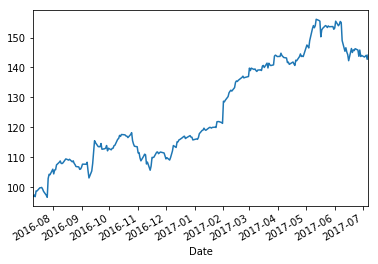

In [ ]:
# Plot the closing price over time to visualize the stock trend.
%matplotlib inline
df['Close'].plot()

<Axes: xlabel='Date'>

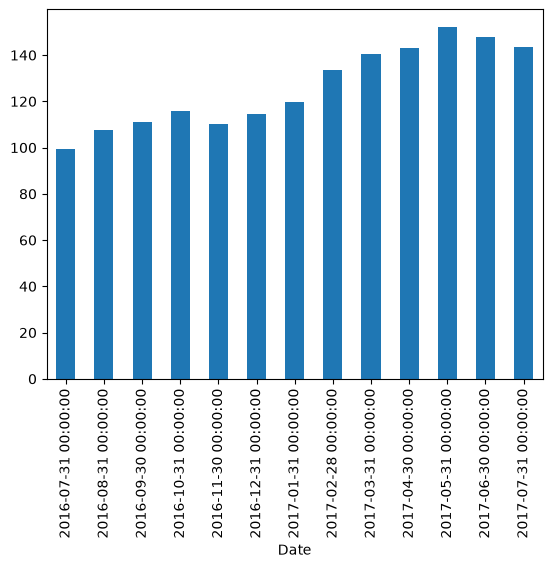

In [29]:
# Plot the monthly average closing price as a bar chart.
df['Close'].resample('ME').mean().plot(kind='bar')